<a href="https://colab.research.google.com/github/TaiwoOlaniyiToheeb/airline_satisfaction_logistic_reg/blob/main/Invistico_Airline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
filepath = '/content/drive/MyDrive/colab files/Invistico_Airline.csv'
df = pd.read_csv(filepath)
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [122]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [123]:
df.isnull().sum()

,0
satisfaction,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0
Gate location,0


In [124]:
df.duplicated().sum()

np.int64(0)

In [125]:
df.shape

(129880, 22)

In [126]:
df.columns

Index(['satisfaction', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient',
       'Food and drink', 'Gate location', 'Inflight wifi service',
       'Inflight entertainment', 'Online support', 'Ease of Online booking',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

In [127]:
df.columns = df.columns.str.lower()

In [128]:
df.columns

Index(['satisfaction', 'customer type', 'age', 'type of travel', 'class',
       'flight distance', 'seat comfort', 'departure/arrival time convenient',
       'food and drink', 'gate location', 'inflight wifi service',
       'inflight entertainment', 'online support', 'ease of online booking',
       'on-board service', 'leg room service', 'baggage handling',
       'checkin service', 'cleanliness', 'online boarding',
       'departure delay in minutes', 'arrival delay in minutes'],
      dtype='object')

In [129]:
df['satisfaction'].value_counts()

,count
satisfaction,
satisfied,71087
dissatisfied,58793


In [130]:
df.columns = df.columns.str.replace(' ', '_')

# EDA

In [131]:
df.groupby('customer_type')['satisfaction'].value_counts()

customer_type      satisfaction
Loyal Customer     satisfied       65387
                   dissatisfied    40713
disloyal Customer  dissatisfied    18080
                   satisfied        5700
Name: count, dtype: int64

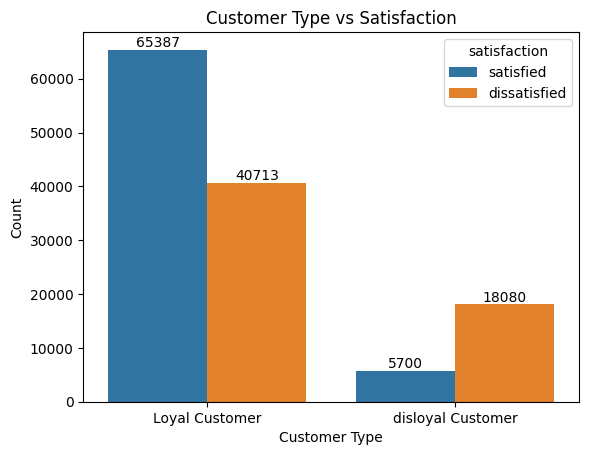

In [132]:
ax = sns.countplot(x = 'customer_type', data = df, hue = 'satisfaction')
for containe in ax.containers:
    ax.bar_label(containe)
plt.title('Customer Type vs Satisfaction')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.show()

In [133]:
df.groupby('type_of_travel')['satisfaction'].value_counts()

type_of_travel   satisfaction
Business travel  satisfied       52356
                 dissatisfied    37337
Personal Travel  dissatisfied    21456
                 satisfied       18731
Name: count, dtype: int64

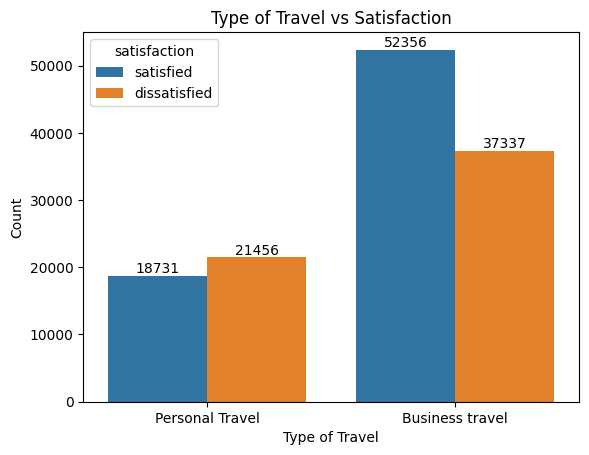

In [134]:
ax = sns.countplot(x = 'type_of_travel', data = df, hue = 'satisfaction')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Type of Travel vs Satisfaction')
plt.xlabel('Type of Travel')
plt.ylabel('Count')
plt.show()

In [135]:
df.groupby('class')['satisfaction'].value_counts()

class     satisfaction
Business  satisfied       44095
          dissatisfied    18065
Eco       dissatisfied    35336
          satisfied       22973
Eco Plus  dissatisfied     5392
          satisfied        4019
Name: count, dtype: int64

In [136]:
percentage = df.groupby('class')['satisfaction'].value_counts(normalize=True) * 100
percentage = percentage.reset_index(name='percentage')
percentage.sort_values(by='percentage', ascending=False)

,class,satisfaction,percentage
0,Business,satisfied,70.937902
2,Eco,dissatisfied,60.601279
4,Eco Plus,dissatisfied,57.294655
5,Eco Plus,satisfied,42.705345
3,Eco,satisfied,39.398721
1,Business,dissatisfied,29.062098


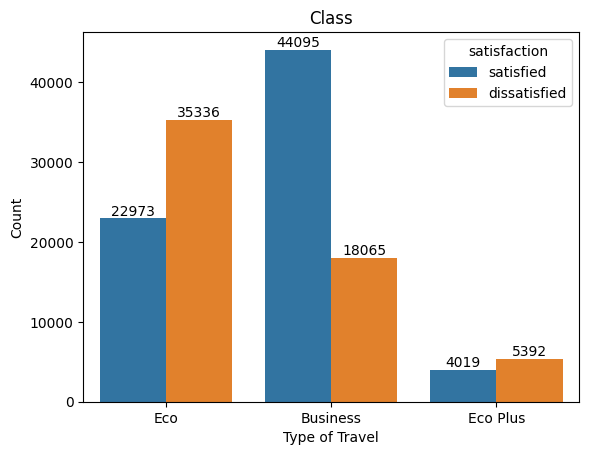

In [137]:
ax = sns.countplot(x = 'class', data = df, hue = 'satisfaction')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Class')
plt.xlabel('Type of Travel')
plt.ylabel('Count')
plt.show()

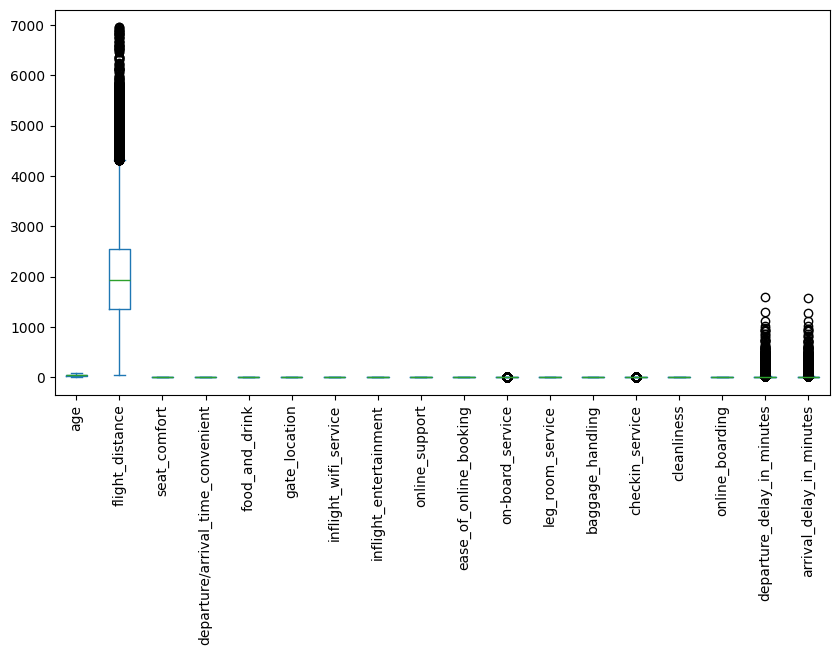

In [138]:
df.plot(kind = 'box', figsize = (10, 5))
plt.xticks(rotation = 90)
plt.show()

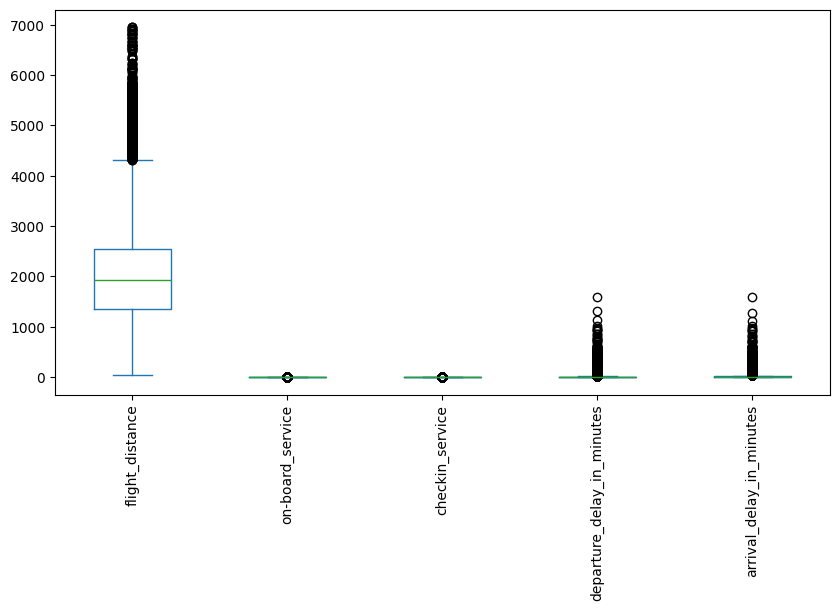

In [139]:
outl = df[['flight_distance', 'on-board_service',  'checkin_service', 'departure_delay_in_minutes', 'arrival_delay_in_minutes']]
outl.plot(kind = 'box', figsize = (10, 5))
plt.xticks(rotation = 90)
plt.show()

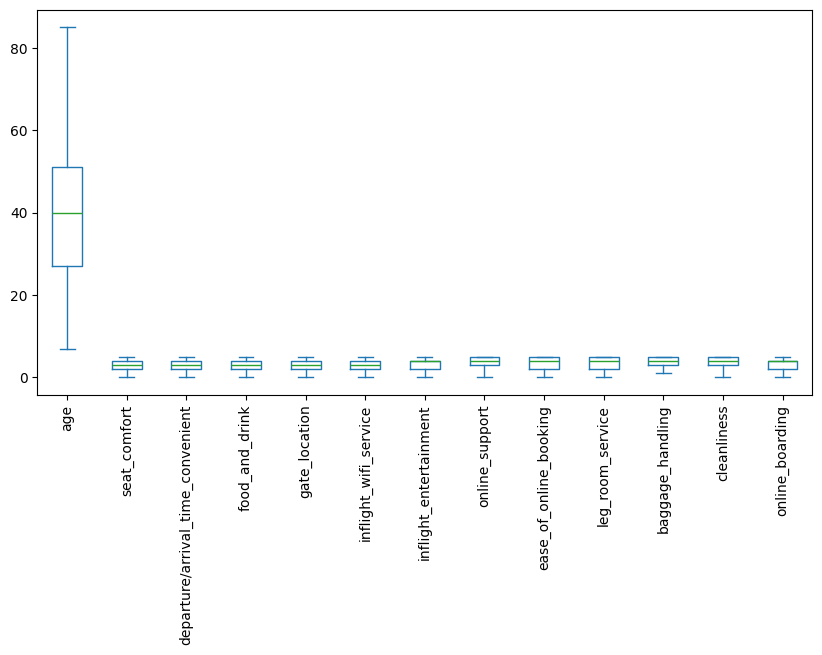

In [140]:
others = df[['age', 'seat_comfort', 'departure/arrival_time_convenient',
       'food_and_drink', 'gate_location', 'inflight_wifi_service',
       'inflight_entertainment', 'online_support', 'ease_of_online_booking',
       'leg_room_service', 'baggage_handling',
       'cleanliness', 'online_boarding']]

others.plot(kind = 'box', figsize = (10, 5))
plt.xticks(rotation = 90)
plt.show()

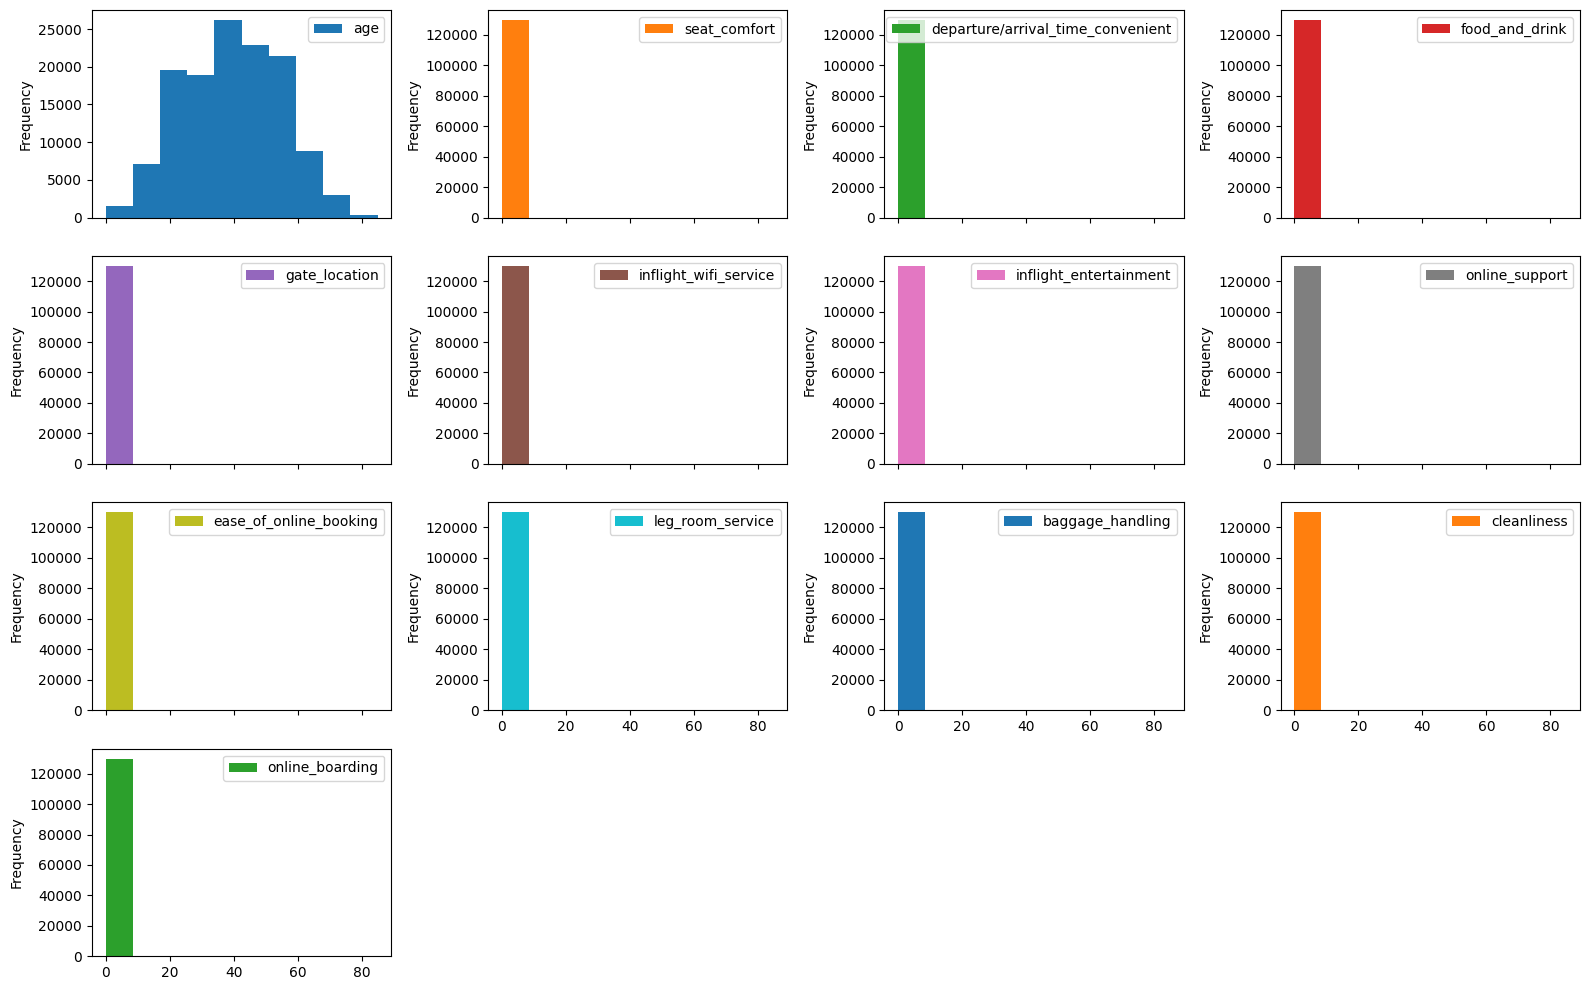

In [141]:
others.plot(kind = 'hist', subplots = True, figsize = (16, 10), layout = (4, 4))
plt.tight_layout()
plt.show()

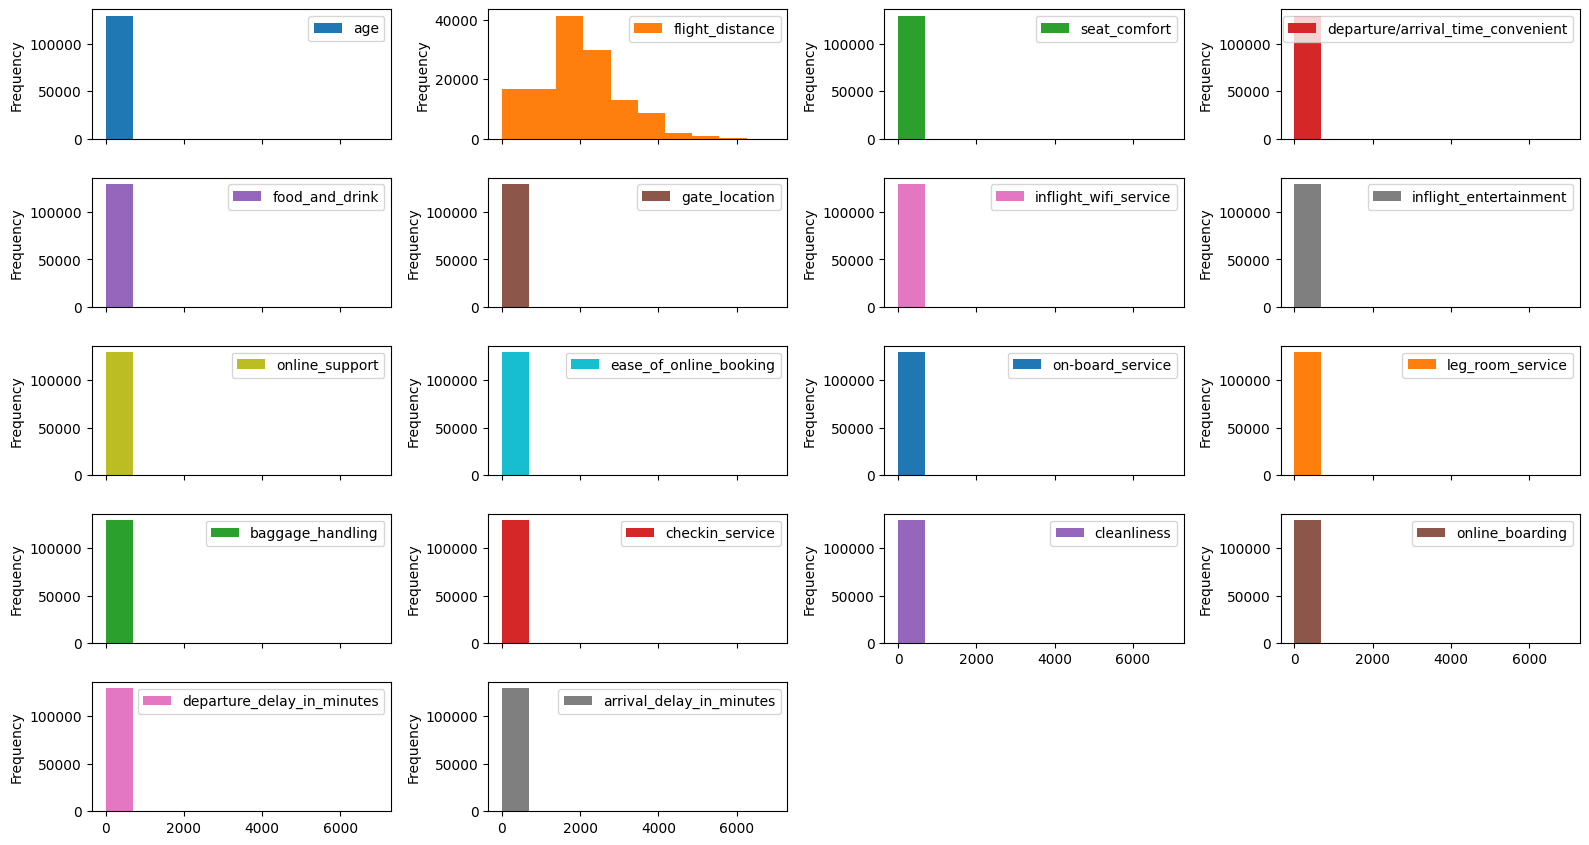

In [142]:
df.plot(kind = 'hist', subplots = True, figsize = (16, 10), layout = (6, 4))
plt.tight_layout()
plt.show()

In [181]:
df.columns

Index(['satisfaction', 'age', 'flight_distance', 'seat_comfort',
       'departure/arrival_time_convenient', 'food_and_drink', 'gate_location',
       'inflight_wifi_service', 'inflight_entertainment', 'online_support',
       'ease_of_online_booking', 'on-board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'cleanliness', 'online_boarding',
       'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'customer_type_disloyal Customer', 'type_of_travel_Personal Travel',
       'class_Eco', 'class_Eco Plus'],
      dtype='object')

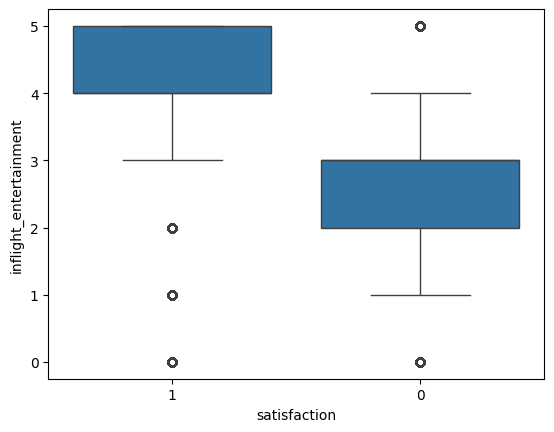

In [182]:
sns.boxplot(x = 'satisfaction', y = 'inflight_entertainment', data = df)
plt.show()

In [143]:
sat_col_cat = {'satisfied' : '1', "dissatisfied" : '0'}
df['satisfaction'] = df['satisfaction'].map(sat_col_cat)

In [144]:
df.head()

,satisfaction,customer_type,age,type_of_travel,class,flight_distance,seat_comfort,departure/arrival_time_convenient,food_and_drink,gate_location,...,online_support,ease_of_online_booking,on-board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes
0,1,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [145]:
df.head()

,satisfaction,customer_type,age,type_of_travel,class,flight_distance,seat_comfort,departure/arrival_time_convenient,food_and_drink,gate_location,...,online_support,ease_of_online_booking,on-board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes
0,1,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [146]:
df['arrival_delay_in_minutes'].agg(['mean', 'median', 'sum'])

,arrival_delay_in_minutes
mean,1.509113e+01
median,0.000000e+00
sum,1.954105e+06


In [147]:

df['arrival_delay_in_minutes'] = df['arrival_delay_in_minutes'].fillna(df['arrival_delay_in_minutes'].median())

In [148]:
cat_col = ['customer_type', 'type_of_travel', 'class']
df = pd.get_dummies(df, columns = cat_col, drop_first = True, dtype = 'int')

<Axes: ylabel='arrival_delay_in_minutes'>

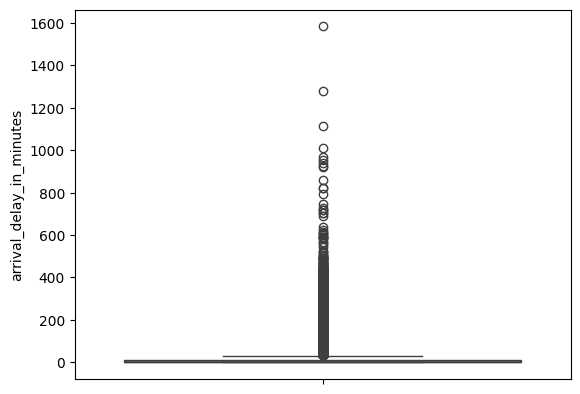

In [149]:
sns.boxplot(y = 'arrival_delay_in_minutes', data = df)

In [150]:
corr_mat = df.corr()
corr_mat

,satisfaction,age,flight_distance,seat_comfort,departure/arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,...,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes,customer_type_disloyal Customer,type_of_travel_Personal Travel,class_Eco,class_Eco Plus
satisfaction,1.000000,0.117971,-0.039224,0.242384,-0.015507,0.120677,-0.012071,0.227062,0.523496,0.390143,...,0.260347,0.266179,0.259330,0.338147,-0.073909,-0.080487,-0.292592,-0.109239,-0.278062,-0.067537
age,0.117971,1.000000,-0.249625,0.008784,0.039055,0.015749,-0.000547,0.013965,0.130511,0.121201,...,-0.015452,0.031845,-0.018271,0.037973,-0.009041,-0.011206,-0.284172,-0.044808,-0.132597,-0.012922
flight_distance,-0.039224,-0.249625,1.000000,-0.042409,0.001350,-0.004649,-0.002409,0.012230,-0.027542,-0.032022,...,0.019768,0.002456,0.009432,0.009604,0.112555,0.109733,0.018938,-0.122762,-0.138107,-0.052151
seat_comfort,0.242384,0.008784,-0.042409,1.000000,0.434951,0.715997,0.405300,0.129131,0.426447,0.120278,...,0.118489,0.041214,0.108475,0.130396,-0.023817,-0.025463,-0.042845,0.016839,0.023528,0.019401
departure/arrival_time_convenient,-0.015507,0.039055,0.001350,0.434951,1.000000,0.527381,0.544259,-0.001974,0.077203,-0.000546,...,0.067396,0.062794,0.067126,-0.000623,0.004395,0.002500,-0.186053,0.191525,0.047451,0.019817
food_and_drink,0.120677,0.015749,-0.004649,0.715997,0.527381,1.000000,0.523328,0.025917,0.367669,0.028554,...,0.036370,0.011898,0.033416,0.013587,-0.013433,-0.014845,-0.048725,-0.031751,-0.046908,-0.005618
gate_location,-0.012071,-0.000547,-0.002409,0.405300,0.544259,0.523328,1.000000,-0.004086,-0.000280,0.002908,...,-0.000401,-0.031859,-0.001705,-0.003043,0.003962,0.003620,-0.000522,-0.013801,0.004071,-0.000543
inflight_wifi_service,0.227062,0.013965,0.012230,0.129131,-0.001974,0.025917,-0.004086,1.000000,0.253823,0.557340,...,0.038251,0.092508,0.038263,0.631786,-0.032900,-0.035198,-0.073400,-0.019321,-0.055314,-0.014853
inflight_entertainment,0.523496,0.130511,-0.027542,0.426447,0.077203,0.367669,-0.000280,0.253823,1.000000,0.441957,...,0.117213,0.224120,0.109451,0.355714,-0.030491,-0.033182,-0.235757,-0.079576,-0.218458,-0.059173
online_support,0.390143,0.121201,-0.032022,0.120278,-0.000546,0.028554,0.002908,0.557340,0.441957,1.000000,...,0.102444,0.206824,0.095726,0.669843,-0.034018,-0.035940,-0.186154,-0.039385,-0.159505,-0.048872


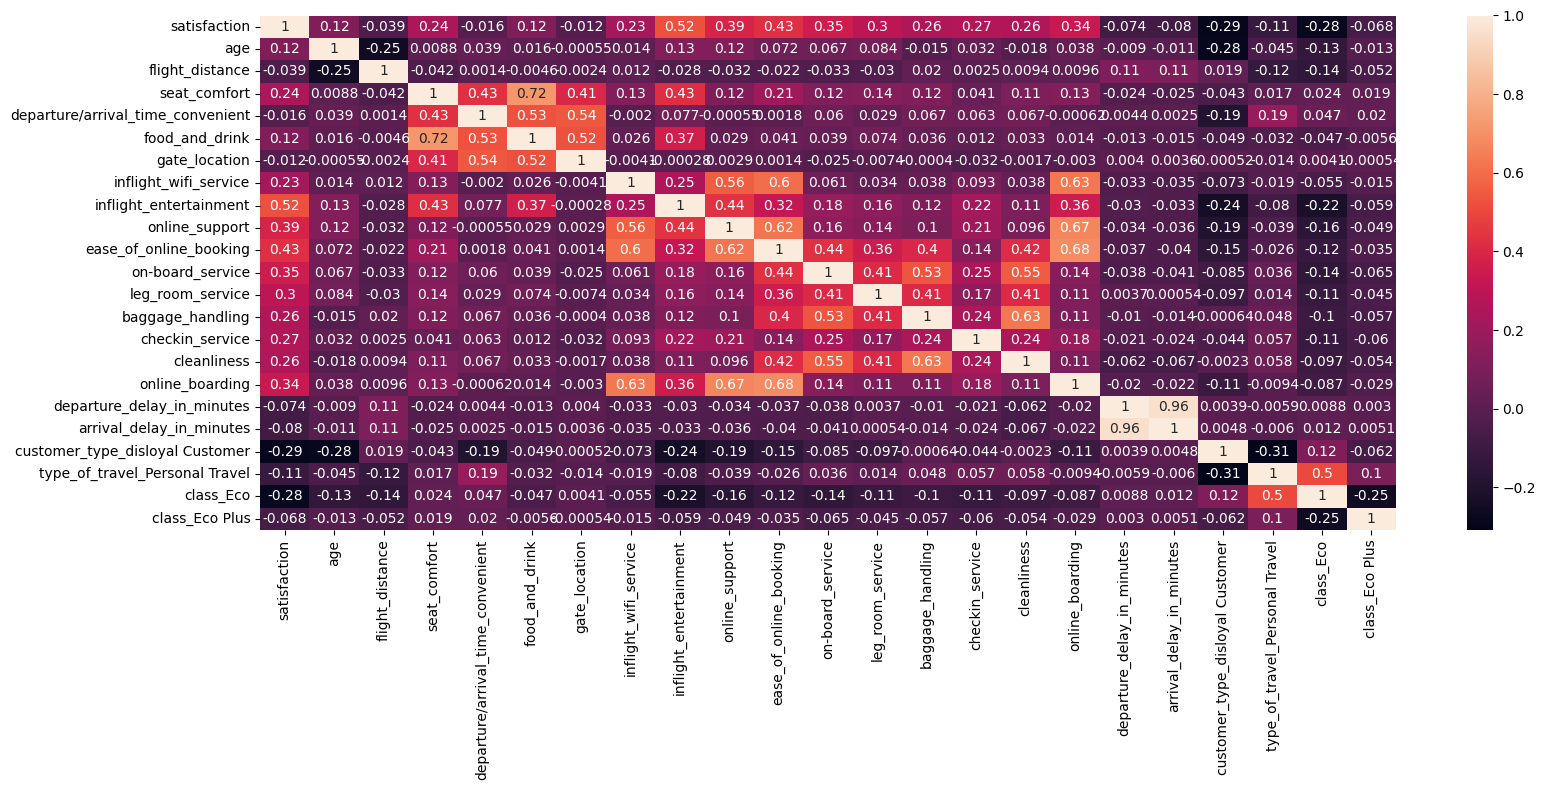

In [151]:
fig, ax = plt.subplots(figsize = (17, 8))
sns.heatmap(corr_mat, annot = True)

plt.tight_layout()
plt.show()

In [152]:
df.head()

,satisfaction,age,flight_distance,seat_comfort,departure/arrival_time_convenient,food_and_drink,gate_location,inflight_wifi_service,inflight_entertainment,online_support,...,baggage_handling,checkin_service,cleanliness,online_boarding,departure_delay_in_minutes,arrival_delay_in_minutes,customer_type_disloyal Customer,type_of_travel_Personal Travel,class_Eco,class_Eco Plus
0,1,65,265,0,0,0,2,2,4,2,...,3,5,3,2,0,0.0,0,1,1,0
1,1,47,2464,0,0,0,3,0,2,2,...,4,2,3,2,310,305.0,0,1,0,0
2,1,15,2138,0,0,0,3,2,0,2,...,4,4,4,2,0,0.0,0,1,1,0
3,1,60,623,0,0,0,3,3,4,3,...,1,4,1,3,0,0.0,0,1,1,0
4,1,70,354,0,0,0,3,4,3,4,...,2,4,2,5,0,0.0,0,1,1,0


In [153]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [154]:
X = df.drop('satisfaction', axis = 1)
y = df['satisfaction']

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [156]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((103904, 22), (25976, 22), (103904,), (25976,))

In [157]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [158]:
lr = LogisticRegression(random_state = 42)
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

In [159]:
y_test = y_test.astype('int')
y_pred = y_pred.astype('int')

In [160]:
accuracy_score(y_test, y_pred)

0.8273021250384971

In [161]:
confusion_mat = confusion_matrix(y_test, y_pred)
confusion_mat

array([[ 9435,  2240],
       [ 2246, 12055]])

In [162]:
2246 + 12055

14301

In [163]:
X_test.shape

(25976, 22)

In [164]:
y_test.value_counts()

,count
satisfaction,
1,14301
0,11675


In [165]:
df['satisfaction'].value_counts()

,count
satisfaction,
1,71087
0,58793


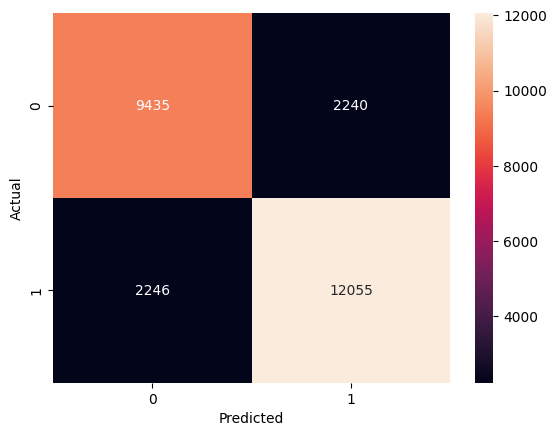

In [166]:
sns.heatmap(confusion_mat, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [167]:
report = classification_report(y_test, y_pred, output_dict = True)
report_df = pd.DataFrame(report).transpose()
report_df.round(4)

,precision,recall,f1-score,support
0,0.8077,0.8081,0.8079,11675.0000
1,0.8433,0.8429,0.8431,14301.0000
accuracy,0.8273,0.8273,0.8273,0.8273
macro avg,0.8255,0.8255,0.8255,25976.0000
weighted avg,0.8273,0.8273,0.8273,25976.0000


In [168]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Precision: 0.8433018537950332
Recall: 0.8429480455912174
F1 Score: 0.8431249125751853


In [169]:
report_df.loc[['0', '1'], ['precision', 'recall', 'f1-score']]

,precision,recall,f1-score
0,0.807722,0.808137,0.807929
1,0.843302,0.842948,0.843125


In [170]:
report_df.loc['1']

,1
precision,0.843302
recall,0.842948
f1-score,0.843125
support,14301.000000


In [171]:
lr.coef_

array([[-0.13580725, -0.1881662 ,  0.40241355, -0.34406031, -0.30609719,
         0.17565247, -0.11871154,  0.9765042 ,  0.13688046,  0.32101372,
         0.39973266,  0.30415916,  0.10890444,  0.35578244,  0.06977573,
         0.185137  ,  0.07884574, -0.26635596, -0.73253405, -0.35633085,
        -0.35358203, -0.20314573]])

In [172]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_[0]*100})
feature_importance.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
7,inflight_entertainment,97.650420
2,seat_comfort,40.241355
10,on-board_service,39.973266
13,checkin_service,35.578244
9,ease_of_online_booking,32.101372
11,leg_room_service,30.415916
15,online_boarding,18.513700
5,gate_location,17.565247
8,online_support,13.688046
12,baggage_handling,10.890444


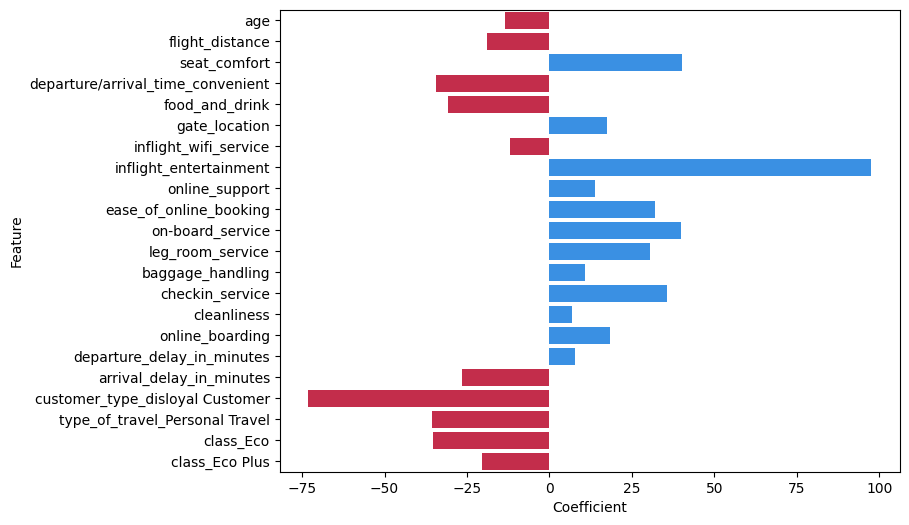

In [180]:
feature_importance['Positive'] = feature_importance['Coefficient'] > 0

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature',
            data=feature_importance, hue='Positive',
            palette={True: 'dodgerblue', False: 'crimson'}, legend=False)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

In [173]:
top_features = feature_importance.sort_values(by='Coefficient', ascending=False).head(12)
top_features

,Feature,Coefficient
7,inflight_entertainment,97.650420
2,seat_comfort,40.241355
10,on-board_service,39.973266
13,checkin_service,35.578244
9,ease_of_online_booking,32.101372
11,leg_room_service,30.415916
15,online_boarding,18.513700
5,gate_location,17.565247
8,online_support,13.688046
12,baggage_handling,10.890444


## Features
The model was fitted and achieved 82.73% accuracy on the test set.

## Confusion Matrix

|                    | Predicted: 0 (Dissatisfied) | Predicted: 1 (Satisfied) |
|--------------------|----------------------------|---------------------------|
| Actual: 0          | 9435                       | 2240                      |
| Actual: 1          | 2246                       | 12055                     |


The model correctly classified 9,435 as Dissatisfied out of 1,167 Dissatisfied passengers and 12,055 as Satisfied out of 14,301 Satisfied passengers.

The model achieves a Precision: 84.33, Recall: 84.29%, F1 Score: 84.31%. This means that 84.33% of the time, the model correctly predict the postive class (satisfied), recall indicates that 84% of the times the model correctly identify the positive class and indicates a strong balance between catching positives values and avoiding false alarms.


## Model Feature Coefficients

The table below shows the impact of each feature on the model prediction. Positive values increase the likelihood of the positive class, while negative values decrease it.

| Feature | Coefficient |
|----------|-------------|
| inflight_entertainment | 97.650420 |
| seat_comfort | 40.241355 |
| on-board_service | 39.973266 |
| checkin_service | 35.578244 |
| ease_of_online_booking | 32.101372 |
| leg_room_service | 30.415916 |
| online_boarding | 18.513700 |
| gate_location | 17.565247 |
| online_support | 13.688046 |
| baggage_handling | 10.890444 |
| departure_delay_in_minutes | 7.884574 |
| cleanliness | 6.977573 |
| inflight_wifi_service | -11.871154 |
| age | -13.580725 |
| flight_distance | -18.816620 |
| class_Eco Plus | -20.314573 |
| arrival_delay_in_minutes | -26.635596 |
| food_and_drink | -30.609719 |
| departure/arrival_time_convenient | -34.406031 |
| class_Eco | -35.358203 |
| type_of_travel_Personal Travel | -35.633085 |
| customer_type_disloyal Customer | -73.253405 |


### Feature Importance Analysis and Business Recommendations

The model results indicate that customer satisfaction is primarily driven by the quality of the onboard experience. Among all features, **inflight entertainment** has the strongest positive influence on satisfaction, followed by **seat comfort**, **on-board service**, **check-in service**, **ease of online booking**, and **leg room service**. This suggests that passengers place significant value on comfort, convenience, and service quality throughout their journey. Digital touchpoints such as online booking, online boarding, and customer support also contribute positively, highlighting the importance of a seamless customer experience before and during travel.

The strongest negative factor is being a **disloyal customer**, indicating that customers without an established relationship with the airline are substantially less likely to report satisfaction. Other notable negative factors include **personal travel**, **economy class travel**, **arrival delays**, **food and drink quality**, and the convenience of departure and arrival times. These findings suggest that leisure travelers and economy-class passengers generally have lower satisfaction levels, while operational inefficiencies and service shortcomings negatively impact the customer experience.

### Business Recommendations

To improve overall customer satisfaction, the airline should prioritize investments in onboard experience, particularly inflight entertainment, seating comfort, cabin service, and digital customer interactions. Enhancing loyalty programs and retention initiatives could help convert disloyal customers into repeat passengers, thereby improving satisfaction levels. Additionally, reducing arrival delays through operational improvements should remain a key focus, as delays significantly diminish customer experience. Finally, targeted improvements in food and beverage offerings and tailored service enhancements for economy-class and personal-travel customers may help address satisfaction gaps within these customer segments.

## Business Insights and Recommendations

### Key Findings

- Improving **inflight entertainment** is likely to have the greatest impact on customer satisfaction, making it the most influential service-related factor in the model.
- Enhancing **seat comfort**, **on-board service**, and **check-in service** could significantly improve the overall passenger experience and increase satisfaction levels.
- Streamlining the **online booking** and **online boarding** processes may improve customer perceptions by reducing friction throughout the travel journey.
- Better **leg room availability** and improved **gate location accessibility** are associated with higher customer satisfaction.
- Efficient **online support** and **baggage handling** contribute positively to customer experience and should be maintained as operational strengths.
- **Disloyal customers** are substantially less likely to be satisfied than loyal customers, indicating a strong relationship between customer retention and satisfaction.
- Passengers traveling in **Economy** and **Economy Plus** classes tend to report lower satisfaction levels compared to premium cabin passengers.
- **Personal travel** customers appear less satisfied than business travelers, suggesting differing expectations and service needs across traveler segments.
- Increased **arrival delays** are strongly associated with lower customer satisfaction, highlighting the importance of operational reliability.
- Lower ratings for **food and drink quality**, **departure/arrival time convenience**, and **inflight Wi-Fi service** are linked to reduced customer satisfaction.

### Business Recommendations

- Invest in upgrading and expanding **inflight entertainment systems**, as improvements in this area are likely to generate the largest increase in customer satisfaction.
- Enhance **seat comfort and cabin service standards** through staff training and service quality initiatives.
- Simplify the **online booking and boarding experience** by reducing process complexity and improving digital platform usability.
- Develop targeted **customer loyalty programs** to encourage repeat patronage and improve satisfaction among currently disloyal customers.
- Implement operational strategies aimed at reducing **arrival delays**, such as schedule optimization and proactive disruption management.
- Improve **food and beverage offerings**, particularly on routes where customer satisfaction scores are lower.
- Upgrade **inflight Wi-Fi reliability and speed** to better meet passenger expectations, especially for travelers who require connectivity during flights.
- Introduce targeted service improvements for **Economy-class passengers**, who represent the segment with the lowest satisfaction levels.
- Create tailored travel packages and customer engagement initiatives for **personal travelers** to address their unique needs and expectations.
- Continuously monitor customer feedback across key service touchpoints to identify emerging satisfaction drivers and areas requiring improvement.

## Business Insights and Recommendations

### Key Findings

- Improving **inflight entertainment** is likely to have the greatest impact on customer satisfaction, making it the most influential service-related factor in the model.
- Enhancing **seat comfort**, **on-board service**, and **check-in service** could significantly improve the overall passenger experience and increase satisfaction levels.
- Streamlining the **online booking** and **online boarding** processes may improve customer perceptions by reducing friction throughout the travel journey.
- Better **leg room availability** and improved **gate location accessibility** are associated with higher customer satisfaction.
- Efficient **online support** and **baggage handling** contribute positively to customer experience and should be maintained as operational strengths.
- **Disloyal customers** are substantially less likely to be satisfied than loyal customers, indicating a strong relationship between customer retention and satisfaction.
- Passengers traveling in **Economy** and **Economy Plus** classes tend to report lower satisfaction levels compared to premium cabin passengers.
- **Personal travel** customers appear less satisfied than business travelers, suggesting differing expectations and service needs across traveler segments.
- Increased **arrival delays** are strongly associated with lower customer satisfaction, highlighting the importance of operational reliability.
- Lower ratings for **food and drink quality**, **departure/arrival time convenience**, and **inflight Wi-Fi service** are linked to reduced customer satisfaction.

### Business Recommendations

- Invest in upgrading and expanding **inflight entertainment systems**, as improvements in this area are likely to generate the largest increase in customer satisfaction.
- Enhance **seat comfort and cabin service standards** through staff training and service quality initiatives.
- Simplify the **online booking and boarding experience** by reducing process complexity and improving digital platform usability.
- Develop targeted **customer loyalty programs** to encourage repeat patronage and improve satisfaction among currently disloyal customers.
- Implement operational strategies aimed at reducing **arrival delays**, such as schedule optimization and proactive disruption management.
- Improve **food and beverage offerings**, particularly on routes where customer satisfaction scores are lower.
- Upgrade **inflight Wi-Fi reliability and speed** to better meet passenger expectations, especially for travelers who require connectivity during flights.
- Introduce targeted service improvements for **Economy-class passengers**, who represent the segment with the lowest satisfaction levels.
- Create tailored travel packages and customer engagement initiatives for **personal travelers** to address their unique needs and expectations.
- Continuously monitor customer feedback across key service touchpoints to identify emerging satisfaction drivers and areas requiring improvement.

## Limitations and Next Steps for Model Deployment

### Limitations

- The model is based on historical customer survey data and may not fully capture future changes in passenger preferences or airline operations.
- Feature coefficients indicate the direction and relative influence of variables on satisfaction but do not imply causation.
- Some important factors affecting customer satisfaction, such as ticket price, flight disruptions, staff behavior, weather conditions, or competitor offerings are not represented in the dataset.
- The model's performance (F1 Score: 84.3%) indicates strong predictive capability, but misclassifications still occur and may impact decision-making if predictions are used operationally.
- The model may be less accurate for customer segments that are underrepresented in the training data.
- Changes in airline services, policies, or customer expectations over time may reduce model accuracy and require periodic retraining.

### Next Steps for Deployment

- Perform parameter and hyperparameter tuning to control and maintain balance between overfitting and underfitting.
- Deploy the model as part of a customer experience monitoring dashboard to identify passengers at risk of dissatisfaction.
- Integrate the model with operational systems to provide near real-time satisfaction predictions after customer interactions or flights.
- Establish a monitoring framework to track model performance, prediction accuracy, and potential model drift over time.
- Collect additional data sources, such as customer feedback comments, ticket pricing information, and flight disruption records, to improve future model versions.
- Conduct A/B testing on recommended service improvements, such as inflight entertainment upgrades or loyalty initiatives, to measure their impact on customer satisfaction.
- Retrain and validate the model regularly using newly collected data to ensure predictions remain accurate and relevant.
- Explore more advanced machine learning models and explainability techniques to improve predictive performance while maintaining business interpretability.
- Develop automated alerts that notify management when satisfaction risk exceeds predefined thresholds for specific routes, customer segments, or service categories.